# Advanced Evaluation for AI-SOC Models

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/unsw_nb15_processed.csv")

X = df.drop(columns=["label"])
y = df["label"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [4]:
rf = joblib.load("../models/random_forest.pkl")
iso = joblib.load("../models/isolation_forest.pkl")

In [5]:
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
rf_auc

1.0

In [6]:
iso_scores = iso.decision_function(X_test)
iso_auc = roc_auc_score(y_test, -iso_scores)
iso_auc

0.867675106668557

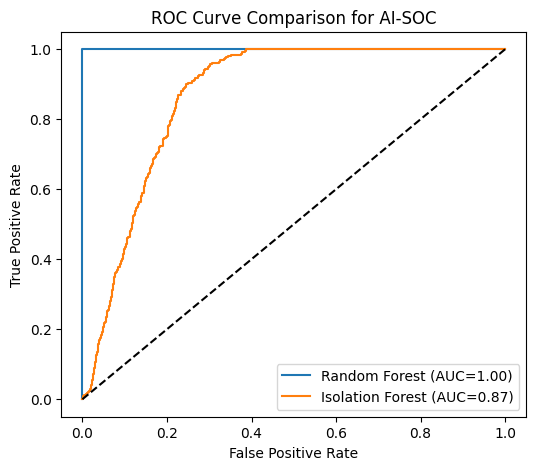

In [7]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
iso_fpr, iso_tpr, _ = roc_curve(y_test, -iso_scores)

plt.figure(figsize=(6,5))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.2f})")
plt.plot(iso_fpr, iso_tpr, label=f"Isolation Forest (AUC={iso_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for AI-SOC")
plt.legend()
plt.show()

In [8]:
def false_positive_rate(y_true, y_pred) :
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

In [9]:
rf_preds = rf.predict(X_test)
iso_preds = np.where(iso.predict(X_test) == -1, 1, 0)

rf_fpr, iso_fpr

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 3.79794911e-04, 1.13938473e-03,
        1.51917964e-03, 2.27876946e-03, 3.41815420e-03, 3.79794911e-03,
        5.31712875e-03, 6.45651348e-03, 7.97569313e-03, 8.73528295e-03,
        9.87466768e-03, 1.06342575e-02, 1.17736422e-02, 1.32928219e-02,
        1.48120015e-02, 1.59513863e-02, 1.67109761e-02, 1.78503608e-02,
        1.86099506e-02, 1.89897455e-02, 1.97493354e-02, 2.12685150e-02,
        2.81048234e-02, 1.00000000e+00]),
 array([0.00000000e+00, 3.79794911e-04, 1.51917964e-03, 1.51917964e-03,
        1.89897455e-03, 1.89897455e-03, 3.79794911e-03, 3.79794911e-03,
        7.59589821e-03, 7.59589821e-03, 7.97569313e-03, 7.97569313e-03,
        1.06342575e-02

In [10]:
test_results = X_test.copy()
test_results["actual"] = y_test.values
test_results["rf_detected"] = rf_preds

In [11]:
attack_events = test_results[test_results["actual"] == 1]

first_detected_index = attack_events[
    attack_events["rf_detected"] == 1
].index.min()

mttd_simulated = first_detected_index - attack_events.index.min()
mttd_simulated

np.int64(0)

In [12]:
summary = pd.DataFrame({
    "Metric": ["ROC-AUC", "False Positive Rate", "Detection capability"],
    "Random Forest": [rf_auc, rf_fpr, "Known Attacks"],
    "Isolation Forest": [iso_auc, iso_fpr, "Unknown / Zero-day"]
})

summary

,Metric,Random Forest,Isolation Forest
0,ROC-AUC,1.0,0.867675
1,False Positive Rate,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.00037979491074819596, 0.00151917964299..."
2,Detection capability,Known Attacks,Unknown / Zero-day
